# Em Dash Prevalence Over Time

This notebook analyzes how often em dashes appear in the concatenated `title + abstract` text over time.

Input data: `data/raw/arxiv_monthly_papers.jsonl`.

In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import re

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

In [5]:
input_path = Path("./../data/raw/arxiv_monthly_papers.jsonl")

if not input_path.exists():
    raise FileNotFoundError(f"Missing input file: {input_path}")

df = pd.read_json(input_path, lines=True)
df.head(2)

,paperId,title,abstract,year,authors,venue,publicationDate,citationCount,influentialCitationCount,fieldsOfStudy,publicationTypes,journal,isOpenAccess,externalIds,url,tldr,source
0,1602.00269v1,Numerical Atrribute Extraction from Clinical Texts,"This paper describes about information extraction system, which is an extension of the system developed by team Hita...",2016,"[{'name': 'Sarath P R'}, {'name': 'Sunil Mandhan'}, {'name': 'Yoshiki Niwa'}]",arXiv,2016-01-31,NaN,NaN,[cs.AI],[preprint],NaN,True,{'ArXiv': '1602.00269v1'},http://arxiv.org/abs/1602.00269v1,NaN,arxiv
1,1602.00203v1,Greedy Deep Dictionary Learning,In this work we propose a new deep learning tool called deep dictionary learning. Multi-level dictionaries are learn...,2016,"[{'name': 'Snigdha Tariyal'}, {'name': 'Angshul Majumdar'}, {'name': 'Richa Singh'}, {'name': 'Mayank Vatsa'}]",arXiv,2016-01-31,NaN,NaN,"[cs.LG, cs.AI, stat.ML]",[preprint],NaN,True,{'ArXiv': '1602.00203v1'},http://arxiv.org/abs/1602.00203v1,NaN,arxiv


In [6]:
df = df.copy()
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df = df[df["year"].between(2016, 2026, inclusive="both")].copy()

df["title"] = df["title"].fillna("").astype(str)
df["abstract"] = df["abstract"].fillna("").astype(str)
df["text"] = (df["title"].str.strip() + " " + df["abstract"].str.strip()).str.strip()
df["word_count"] = df["text"].str.split().str.len().fillna(0).astype(int)
df["em_dash_count"] = df["text"].str.count("--")
df["has_em_dash"] = df["em_dash_count"] > 0
df["em_dashes_per_1k_words"] = df.apply(
    lambda row: (row["em_dash_count"] / row["word_count"] * 1000) if row["word_count"] else 0.0,
    axis=1,
)

df[["year", "word_count", "em_dash_count", "has_em_dash", "em_dashes_per_1k_words"]].head(30)

,year,word_count,em_dash_count,has_em_dash,em_dashes_per_1k_words
0,2016,165,0,False,0.000000
1,2016,97,0,False,0.000000
2,2016,133,0,False,0.000000
3,2016,219,0,False,0.000000
4,2016,62,0,False,0.000000
5,2016,157,1,True,6.369427
6,2016,277,0,False,0.000000
7,2016,54,0,False,0.000000
8,2016,112,0,False,0.000000
9,2016,194,0,False,0.000000


In [7]:
yearly = (
    df.groupby("year", dropna=False)
      .agg(
          papers=("text", "size"),
          papers_with_em_dash=("has_em_dash", "sum"),
          em_dash_count=("em_dash_count", "sum"),
          total_words=("word_count", "sum"),
      )
      .reset_index()
)

yearly["share_of_papers_with_em_dash"] = yearly["papers_with_em_dash"] / yearly["papers"]
yearly["em_dashes_per_1k_words"] = yearly.apply(
    lambda row: (row["em_dash_count"] / row["total_words"] * 1000) if row["total_words"] else 0.0,
    axis=1,
)

yearly

,year,papers,papers_with_em_dash,em_dash_count,total_words,share_of_papers_with_em_dash,em_dashes_per_1k_words
0,2016,60,4,6,9348,0.066667,0.641849
1,2017,60,4,8,9976,0.066667,0.801925
2,2018,60,6,10,9836,0.100000,1.016673
3,2019,60,8,13,10650,0.133333,1.220657
4,2020,60,4,7,10082,0.066667,0.694307
5,2021,60,3,3,11363,0.050000,0.264015
6,2022,60,4,7,11438,0.066667,0.611995
7,2023,60,2,5,11389,0.033333,0.439020
8,2024,60,6,11,11289,0.100000,0.974400
9,2025,60,6,11,11065,0.100000,0.994126


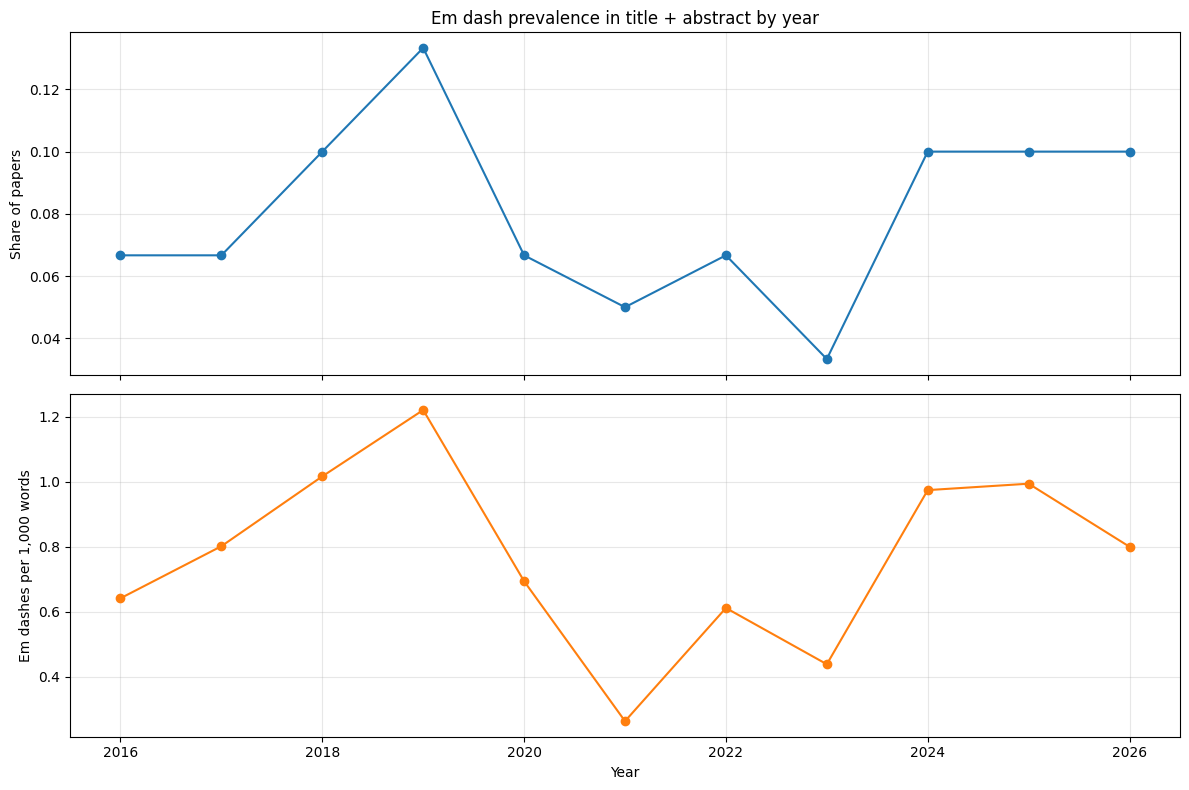

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(yearly["year"], yearly["share_of_papers_with_em_dash"], marker="o")
axes[0].set_ylabel("Share of papers")
axes[0].set_title("Em dash prevalence in title + abstract by year")
axes[0].grid(True, alpha=0.3)

axes[1].plot(yearly["year"], yearly["em_dashes_per_1k_words"], marker="o", color="tab:orange")
axes[1].set_ylabel("Em dashes per 1,000 words")
axes[1].set_xlabel("Year")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

In [9]:
summary = yearly[["year", "papers", "papers_with_em_dash", "share_of_papers_with_em_dash", "em_dashes_per_1k_words"]].copy()
summary.sort_values("year")

,year,papers,papers_with_em_dash,share_of_papers_with_em_dash,em_dashes_per_1k_words
0,2016,60,4,0.066667,0.641849
1,2017,60,4,0.066667,0.801925
2,2018,60,6,0.100000,1.016673
3,2019,60,8,0.133333,1.220657
4,2020,60,4,0.066667,0.694307
5,2021,60,3,0.050000,0.264015
6,2022,60,4,0.066667,0.611995
7,2023,60,2,0.033333,0.439020
8,2024,60,6,0.100000,0.974400
9,2025,60,6,0.100000,0.994126


In [11]:


def sentence_lengths(text):
    sentences = re.split(r'[.!?]+', text)
    lengths = [len(s.split()) for s in sentences if len(s.split()) > 0]
    return lengths

df["sentence_lengths"] = df["text"].apply(sentence_lengths)

df["sent_len_mean"] = df["sentence_lengths"].apply(lambda x: np.mean(x) if x else 0)
df["sent_len_std"] = df["sentence_lengths"].apply(lambda x: np.std(x) if x else 0)

# Key signal
df["sent_len_cv"] = df["sent_len_std"] / (df["sent_len_mean"] + 1e-6)

In [12]:
def ttr(text):
    tokens = text.lower().split()
    if not tokens:
        return 0
    return len(set(tokens)) / len(tokens)

df["ttr"] = df["text"].apply(ttr)

In [13]:
markers = [
    "overall", "in conclusion", "this paper", "this study",
    "we propose", "we present", "we demonstrate",
    "results show", "our results", "in this work"
]

for m in markers:
    df[f"marker_{m.replace(' ', '_')}"] = df["text"].str.lower().str.count(m)

df["marker_density"] = df[[c for c in df.columns if c.startswith("marker_")]].sum(axis=1) / (df["word_count"] + 1)

In [14]:
hedges = ["may", "might", "could", "suggest", "indicate"]
certainty = ["demonstrate", "prove", "show", "confirm"]

df["hedge_count"] = df["text"].str.lower().apply(lambda x: sum(x.count(h) for h in hedges))
df["certainty_count"] = df["text"].str.lower().apply(lambda x: sum(x.count(c) for c in certainty))

df["hedge_ratio"] = df["hedge_count"] / (df["word_count"] + 1)
df["certainty_ratio"] = df["certainty_count"] / (df["word_count"] + 1)

In [ ]:
def repetition_score(text, n=3):
    tokens = text.lower().split()
    ngrams = zip(*[tokens[i:] for i in range(n)])
    counts = Counter(ngrams)
    if not counts:
        return 0
    repeated = sum(c for c in counts.values() if c > 1)
    return repeated / len(tokens)

df["trigram_repetition"] = df["text"].apply(repetition_score)

In [16]:
df["semicolon_count"] = df["text"].str.count(";")

df["semicolon_per_1k"] = df["semicolon_count"] / (df["word_count"] + 1) * 1000

Total feature columns found: 26
['has_em_dash', 'em_dash_count', 'em_dashes_per_1k_words', 'sent_len_mean', 'sent_len_std', 'sent_len_cv', 'ttr', 'marker_density', 'hedge_count', 'certainty_count', 'hedge_ratio', 'certainty_ratio', 'trigram_repetition', 'semicolon_count', 'semicolon_per_1k', 'marker_overall', 'marker_in_conclusion', 'marker_this_paper', 'marker_this_study', 'marker_we_propose', 'marker_we_present', 'marker_we_demonstrate', 'marker_results_show', 'marker_our_results', 'marker_in_this_work', 'marker_density_z']

Feature: has_em_dash
has_em_dash
False    571
True      49
Name: count, dtype: int64

Feature: em_dash_count
em_dash_count
0    571
1     25
2     17
3      3
4      4
Name: count, dtype: int64

Feature: em_dashes_per_1k_words
em_dashes_per_1k_words
(-0.030100000000000002, 2.913]    571
(2.913, 5.825]                     14
(5.825, 8.738]                     12
(8.738, 11.65]                     12
(11.65, 14.563]                     2
(14.563, 17.476]           

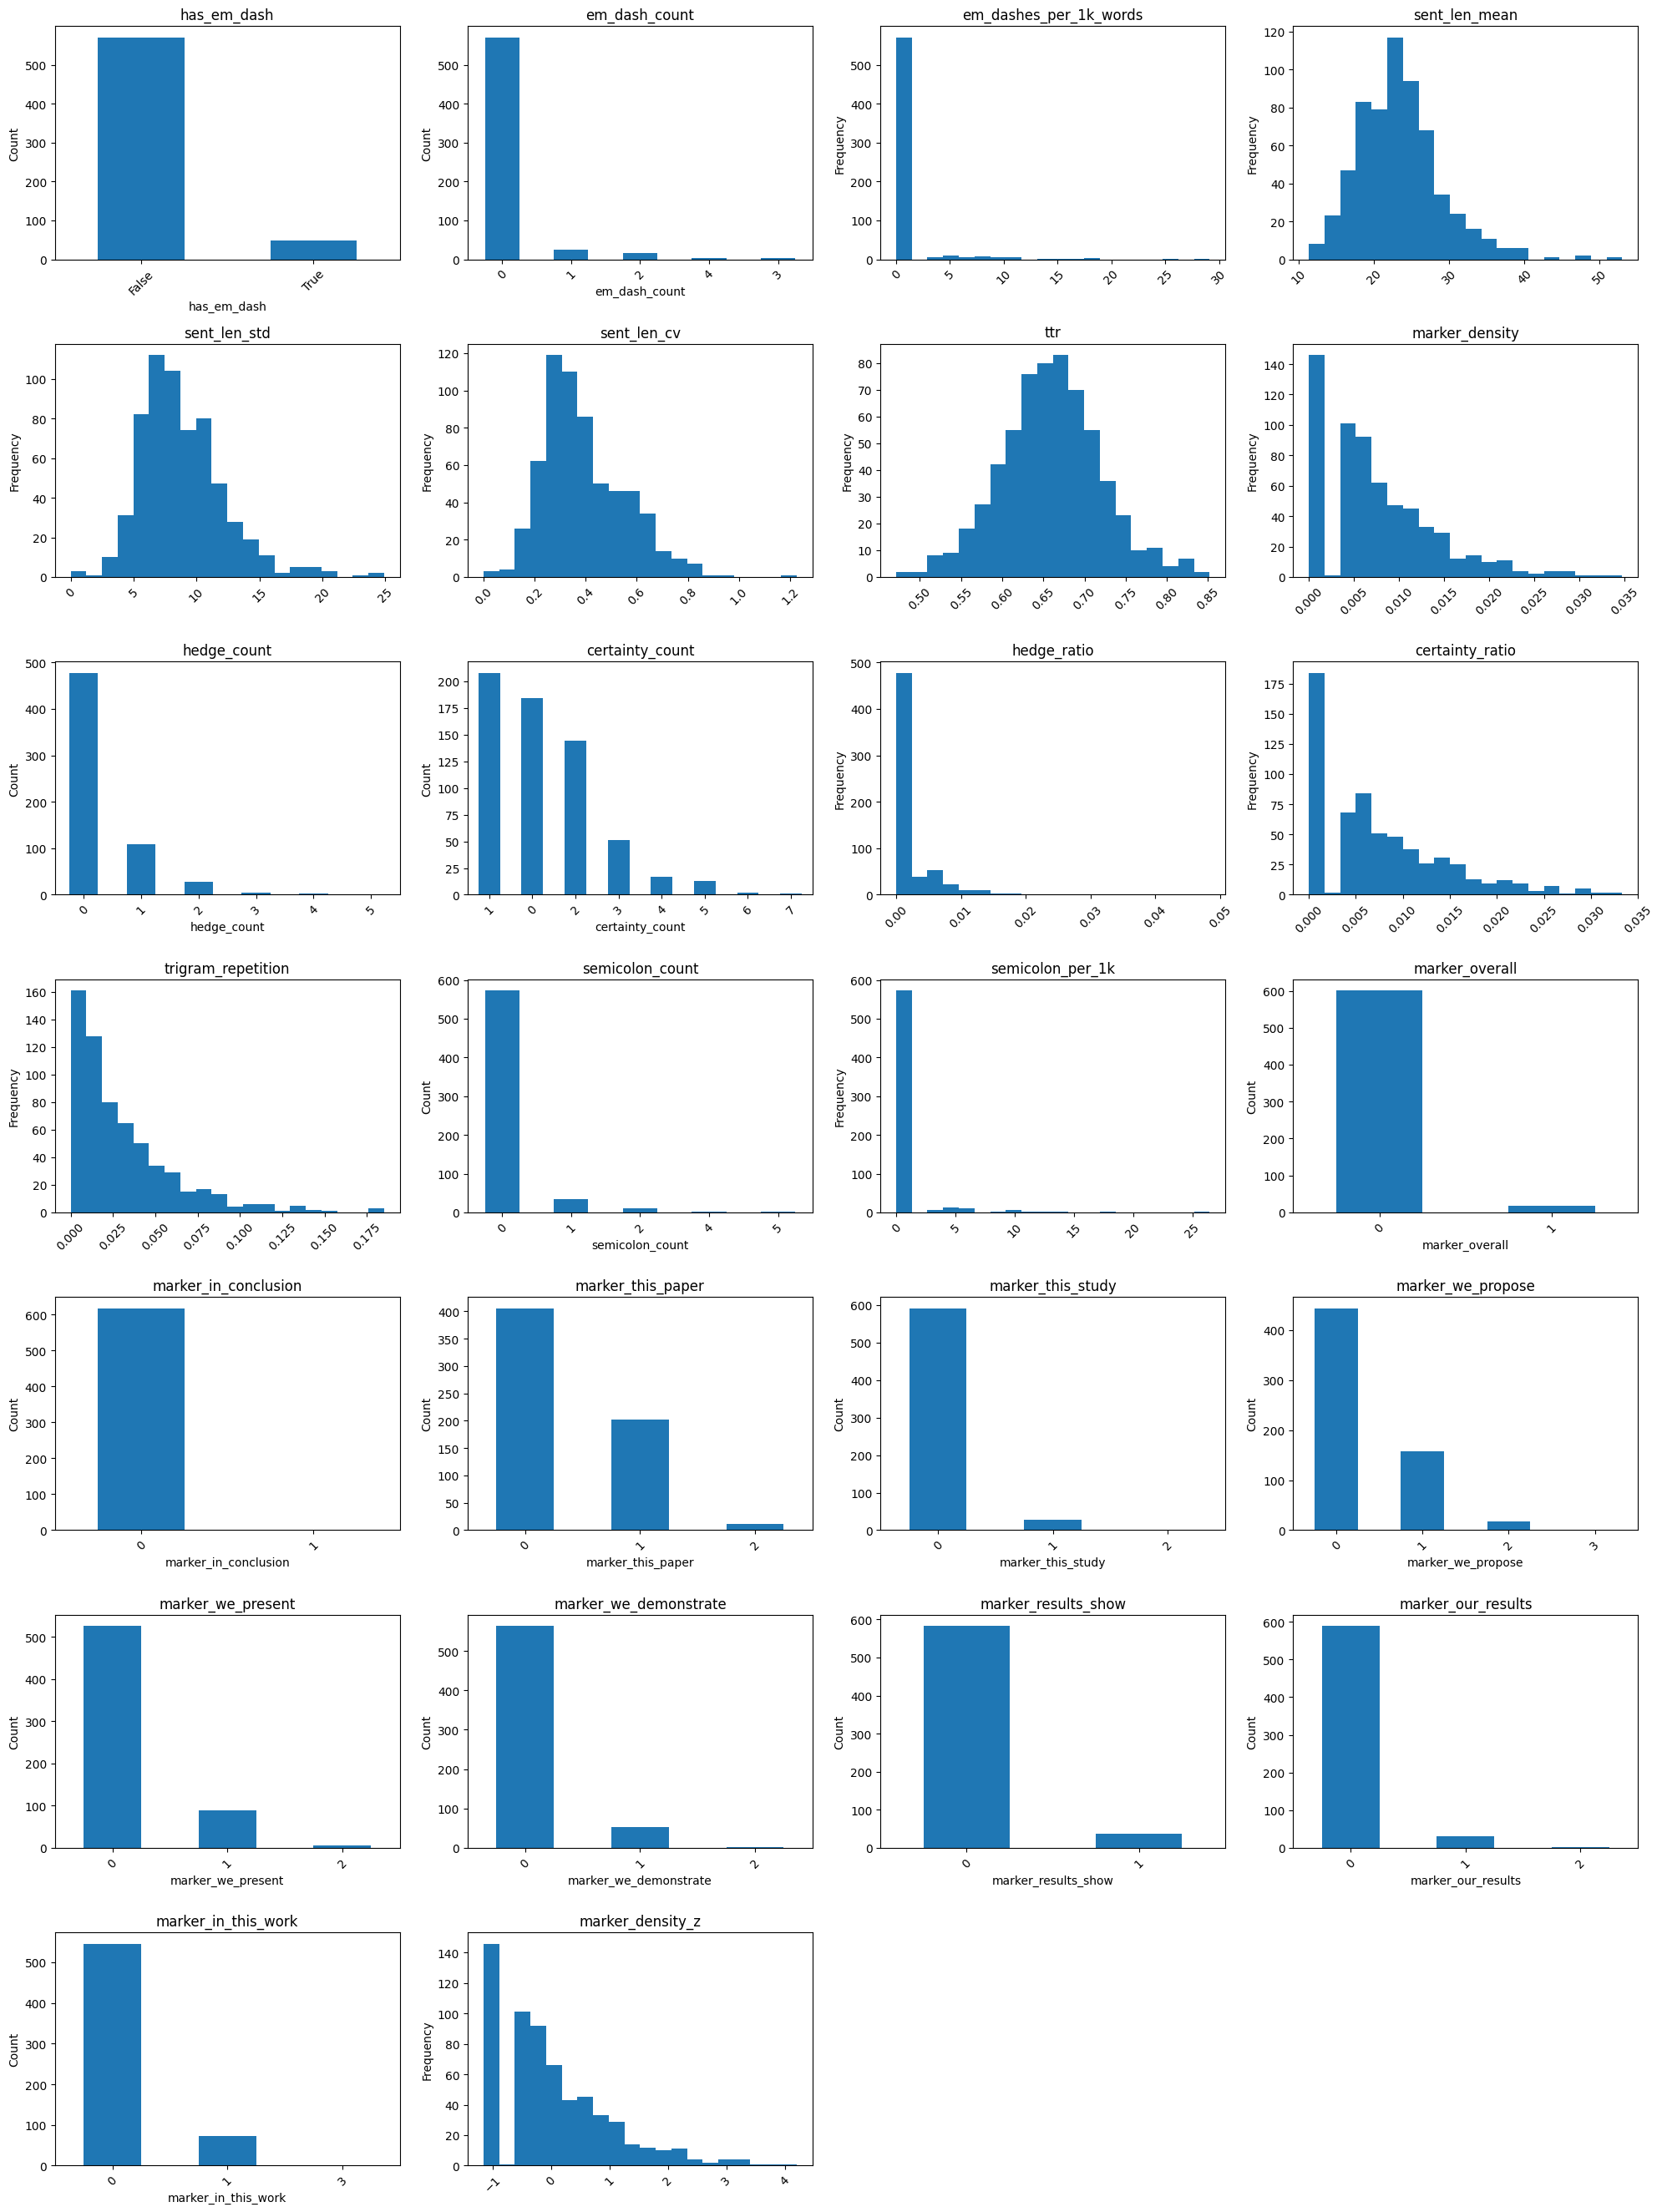

In [19]:
# Feature columns collected in this notebook
feature_columns = [
    "has_em_dash",
    "em_dash_count",
    "em_dashes_per_1k_words",
    "sent_len_mean",
    "sent_len_std",
    "sent_len_cv",
    "ttr",
    "marker_density",
    "hedge_count",
    "certainty_count",
    "hedge_ratio",
    "certainty_ratio",
    "trigram_repetition",
    "semicolon_count",
    "semicolon_per_1k",
]
feature_columns += [c for c in df.columns if c.startswith("marker_")]
feature_columns = list(dict.fromkeys([c for c in feature_columns if c in df.columns]))

print(f"Total feature columns found: {len(feature_columns)}")
print(feature_columns)

# Print frequency tables for every feature.
# For low-cardinality features, show exact counts; otherwise show binned frequencies.
for col in feature_columns:
    print("\n" + "=" * 80)
    print(f"Feature: {col}")

    series = df[col]
    unique_non_na = series.dropna().nunique()

    if pd.api.types.is_bool_dtype(series) or unique_non_na <= 20:
        freq = series.value_counts(dropna=False).sort_index()
        print(freq)
    else:
        binned = pd.cut(series.astype(float), bins=10, include_lowest=True)
        freq = binned.value_counts(dropna=False).sort_index()
        print(freq)

# Visualize frequency distributions for all features
n = len(feature_columns)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_columns):
    ax = axes[i]
    series = df[col]
    unique_non_na = series.dropna().nunique()

    if pd.api.types.is_bool_dtype(series) or unique_non_na <= 20:
        vc = series.value_counts(dropna=False)
        vc.plot(kind="bar", ax=ax)
        ax.set_ylabel("Count")
    else:
        ax.hist(series.dropna().astype(float), bins=20)
        ax.set_ylabel("Frequency")

    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

# Hide unused subplot axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

In [ ]:
# Plot feature frequencies over time (year-by-year).
if "feature_columns" not in globals() or not feature_columns:
    feature_columns = [
        "has_em_dash",
        "em_dash_count",
        "em_dashes_per_1k_words",
        "sent_len_mean",
        "sent_len_std",
        "sent_len_cv",
        "ttr",
        "marker_density",
        "hedge_count",
        "certainty_count",
        "hedge_ratio",
        "certainty_ratio",
        "trigram_repetition",
        "semicolon_count",
        "semicolon_per_1k",
    ]
    feature_columns += [c for c in df.columns if c.startswith("marker_")]
    feature_columns = list(dict.fromkeys([c for c in feature_columns if c in df.columns]))

# Convert to numeric for robust aggregation (bool -> 0/1, invalid -> NaN).
plot_df = df[["year"] + feature_columns].copy()
for col in feature_columns:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

yearly_feature_freq = (
    plot_df.groupby("year", dropna=False)[feature_columns]
    .mean()
    .reset_index()
    .sort_values("year")
)

print("Yearly mean frequency/value per paper for each feature:")
display(yearly_feature_freq)

n = len(feature_columns)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_columns):
    ax = axes[i]
    ax.plot(yearly_feature_freq["year"], yearly_feature_freq[col], marker="o", linewidth=1.8)
    ax.set_title(col)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean per paper")
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()